In [82]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

# import import_ipynb
from graph_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
x = generate_graphs(22)
G, n, _ = x[1]

number of graphs for n=22 : 2


initial removal


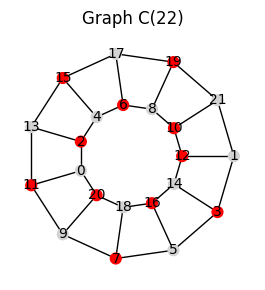

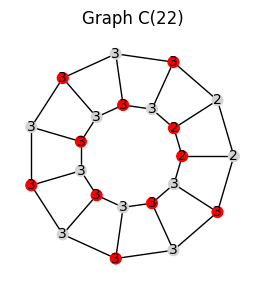

removal of element  2  ->  {'infected': 1, 'infection_influence': 3, 'infection_count': 0}


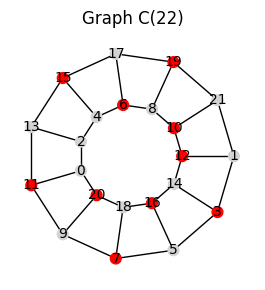

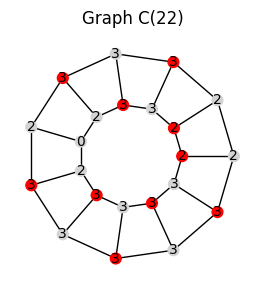

removal of element  3  ->  {'infected': 1, 'infection_influence': 3}


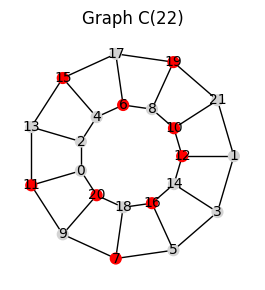

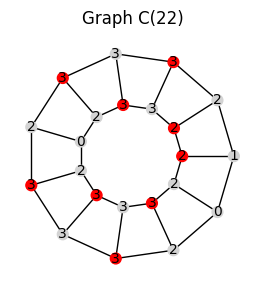

removal of element  6  ->  {'infected': 1, 'infection_influence': 3}


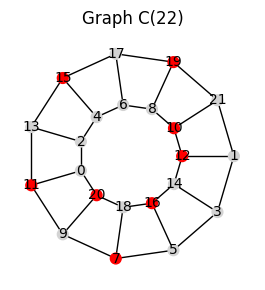

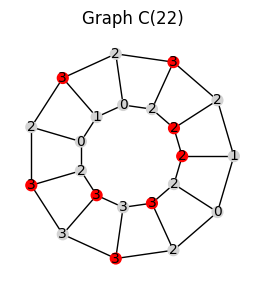

In [106]:
for i in range(len(G.nodes)):
    G.nodes[i]["infected"] = 1


def minimise_infection(G, v=0):
    layers = list(nx.bfs_layers(G, v))
    # print(layers)
    
    for i in range(0, len(layers), 2):
        layer = layers[i]
        # print(layer)
    
        for x in layer:
            G.nodes[x]["infected"] = 0

def calc_graph_values(G):
    for i, e in enumerate(G):
        if not G.nodes[i].get("infected"):
            infected_count = 0
    
            for y in G.neighbors(e):
                if G.nodes[y].get("infected"):
                    infected_count += 1
    
            G.nodes[i]["infection_count"] = infected_count
    
        # print(e, G.nodes[i])
    
    
    for i, e in enumerate(G.nodes):
        if G.nodes[i].get("infected"):
            c = 0
            for y in G.neighbors(e):
                if G.nodes[y].get("infection_count"):
                    c += 1
    
            G.nodes[i]["infection_influence"] = c
    
        # print(e, G.nodes[i])

    potential_candidates = []
    for i, e in enumerate(G.nodes):
        if G.nodes[i].get("infected") and G.nodes[y].get("infection_count") == 3:
            potential_candidates.append(e)

    return potential_candidates


def display_graph_stage(G):
    labels = {e: G.nodes[i].get("infection_count") if not G.nodes[i].get("infected") else G.nodes[i].get("infection_influence")  for i, e in enumerate(G.nodes)}
    display_graph2(G, figsize=(3, 3), show_title=True, with_labels=True, pos=prism_pos(G))
    display_graph2(G, figsize=(3, 3), show_title=True, labels=labels, pos=prism_pos(G))
    # display_graph2(G, figsize=(6,5), show_title=True, labels=labels, pos=distance_partitions_pos(G, v=3))
    # display_graph2(G, figsize=(3,3), show_title=True, pos=prism_pos(G), labels=labels)



# 1. stage
print("initial removal")
minimise_infection(G, 0)
pc = calc_graph_values(G)
display_graph_stage(G)


e = pc[0]
print("removal of element ", e, " -> ", G.nodes[pc[0]])
G.nodes[pc[0]]["infected"] = False
minimise_infection(G, 0)
pc = calc_graph_values(G)
display_graph_stage(G)



e = pc[0]
print("removal of element ", e, " -> ", G.nodes[pc[0]])
G.nodes[pc[0]]["infected"] = False
minimise_infection(G, 0)
pc = calc_graph_values(G)
display_graph_stage(G)



e = pc[0]
print("removal of element ", e, " -> ", G.nodes[pc[0]])
G.nodes[pc[0]]["infected"] = False
minimise_infection(G, 0)
pc = calc_graph_values(G)
display_graph_stage(G)

# G.nodes[pc[0]]["infected"] = False

# color_distance_partitions(G, v=3, pos=prism_pos, with_labels=True)
# visualize_distance_partitions(G, 3, figsize=(4, 2), with_labels=True)
# visualize_distance_partitions(G, 11, figsize=(4, 2), with_labels=True)


# for i in G.nodes:
#     visualize_distance_partitions(G, i, figsize=(4, 2))


# pick a random starting infected vertex


number of graphs for n=22 : 2
[[0], [21, 1, 11], [10, 20, 2, 12], [9, 19, 3, 13], [8, 18, 4, 14], [7, 17, 5, 15], [6, 16]]


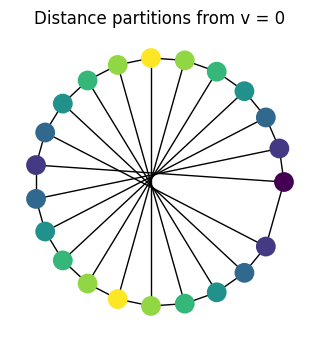

node_colors [0, 1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1]


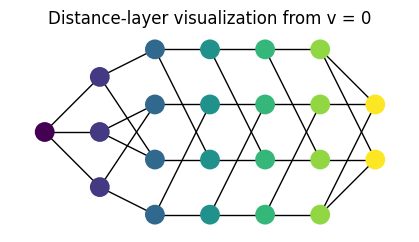

[[0], [20, 2, 11], [9, 18, 4, 13], [7, 16, 6, 15], [5, 14, 8, 17], [3, 12, 10, 19], [1, 21]]


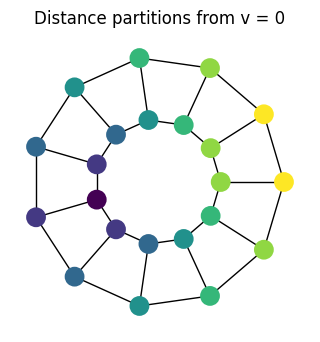

node_colors [0, 6, 1, 5, 2, 4, 3, 3, 4, 2, 5, 1, 5, 2, 4, 3, 3, 4, 2, 5, 1, 6]


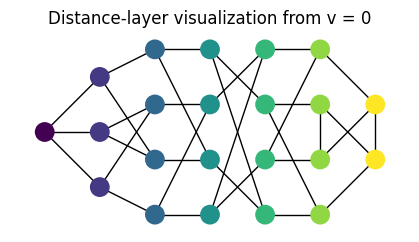

In [62]:
graphs = generate_graphs(22)

for G, _, a in graphs:
    if a == 1:
        color_distance_partitions(G, pos=mobius_pos)
    else:
        color_distance_partitions(G, pos=prism_pos)
    
    visualize_distance_partitions(G, 0, figsize=(4, 2))